# Etapa 1 — Análise Exploratória de Dados (EDA)

**Projeto:** TCC SBO — Surrogate-Based Optimization para colunas de destilação  
**Dados:** Sultan et al. (2025) — LHS-2000, 1921 amostras convergidas  
**Referência:** REF1 — Computers and Chemical Engineering, v.203, 2025 (109324)

---

## De-para: EDA do paper (REF1) × EDA deste TCC

| # | Análise | REF1 faz? | TCC faz? | Observação |
|---|---------|-----------|----------|------------|
| 1.1 | Matriz de correlação de Pearson (inputs × outputs) — heatmap | ✅ | ✅ | Reprodução direta; referência para validar os mesmos padrões |
| 1.2 | Análise de sensibilidade 1D (efeito de T1, P1, RFF sobre outputs) | ✅ | ✅ | Paper apresenta gráficos de efeito marginal; reproduzimos variando uma variável com as demais fixas na mediana |
| 1.3 | Distribuições marginais dos inputs (histogramas) | ❌ | ✅ | Paper não apresenta; incluímos para verificar uniformidade do LHS e ausência de outliers |
| 1.4 | Distribuições dos outputs (histogramas + estatísticas) | ❌ | ✅ | Relevante para entender a variabilidade das saídas e a dificuldade de predição |
| 1.5 | Verificação da assinatura LHS (uniformidade por bin) | ❌ | ✅ | Análise adicional para confirmar a técnica de amostragem dos dados públicos |
| — | Comparação entre técnicas de amostragem (LHS vs MC vs SOBOL) | ✅ | ❌ | Paper analisa 15 combinações (3 técnicas × 5 tamanhos); repositório publica apenas LHS-2000 — não reproduzível |
| — | Análise de efeito do tamanho amostral sobre performance dos modelos | ✅ | ❌ | Mesma restrição acima — apenas n=2000 disponível |

**Nota RFF:** a coluna `RFF` no dataset representa *fração de purga* (0.01–0.25). O paper define `RFF` como *fração de reciclo* (0.75–0.99). Relação: `RFF_paper = 1 − RFF_dataset`. Os gráficos usam os dados brutos; a conversão é aplicada apenas ao reportar resultados do otimizador (Etapa 4).

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── paths ──────────────────────────────────────────────────────────────────
DATA_DIR = Path("ARTEFATOS/ETAPA_0")
OUT_DIR  = Path("ARTEFATOS/ETAPA_1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── constantes ─────────────────────────────────────────────────────────────
INPUTS  = ["Recomp", "HX1", "HX2", "C1 RR", "C1 BR", "C2 RR", "C2 BR", "RFF"]
OUTPUTS = ["Methanol Flow", "Purity", "Energy"]
INPUT_LABELS  = ["P1", "T1", "T2", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"]
OUTPUT_LABELS = ["M_CH3OH (kg/hr)", "x_CH3OH (–)", "ET (kW)"]
OUTPUT_SHORT  = ["M_CH3OH", "x_CH3OH", "ET"]

STYLE = dict(style="whitegrid", font_scale=1.15)
sns.set_theme(**STYLE)

# ── carga dos dados ─────────────────────────────────────────────────────────
train_raw = pd.read_excel(DATA_DIR / "/Users/lorenzoferreira/Documents/UFRGS/TCC_SBO/ARTEFATOS/ETAPA_0/Training-Data-Formated.xlsx")
df = train_raw[train_raw["Status"] == "Results Available"].copy().reset_index(drop=True)

print(f"Amostras após filtro Status: {len(df)} (de {len(train_raw)} totais)")
df[INPUTS + OUTPUTS].describe().round(3)

Amostras após filtro Status: 1921 (de 2000 totais)


,Recomp,HX1,HX2,C1 RR,C1 BR,C2 RR,C2 BR,RFF,Methanol Flow,Purity,Energy
count,1921.000,1921.000,1921.000,1921.000,1921.000,1921.000,1921.000,1921.000,1921.000,1921.000,1921.000
mean,75.069,250.074,90.000,5.519,5.261,5.502,5.292,0.131,5684.319,0.952,36547.215
std,14.432,28.842,2.890,2.600,2.735,2.600,2.745,0.069,2854.894,0.079,16589.058
min,50.001,200.027,85.002,1.001,0.502,1.001,0.502,0.010,375.798,0.639,8768.459
25%,62.680,225.102,87.493,3.269,2.915,3.240,2.911,0.072,3308.308,0.943,23879.782
50%,75.062,250.235,90.023,5.528,5.248,5.510,5.315,0.131,5461.434,0.994,34400.940
75%,87.558,274.973,92.509,7.770,7.628,7.732,7.677,0.190,7719.079,0.997,46272.430
max,99.996,299.963,94.995,9.996,9.994,9.998,9.998,0.250,13151.848,0.998,107795.548


---

## 1.1 — Matriz de Correlação de Pearson

Correlação de Pearson entre os 8 inputs e os 3 outputs. O paper (REF1) apresenta um heatmap semelhante e identifica os inputs mais relevantes por output:

- **M_CH3OH:** T1 (HX1), P1 (Recomp), RFF
- **x_CH3OH:** RRC1 (C1 RR), BRC1 (C1 BR)
- **ET:** RFF, T1 (HX1), BRC1 (C1 BR), RRC2 (C2 RR)

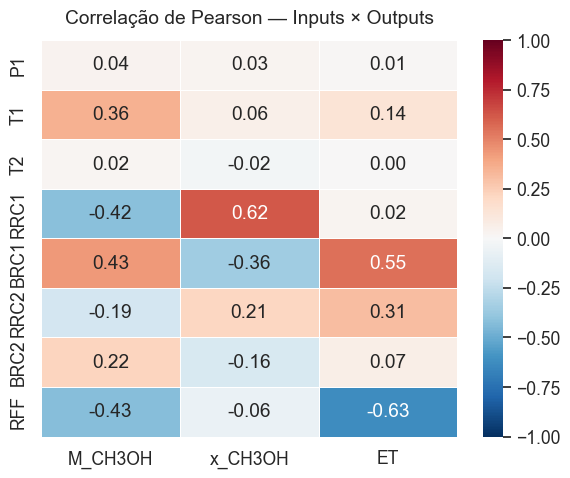


Correlações mais altas (|r| > 0.30):
  M_CH3OH: BRC1=0.43, RFF=-0.43, RRC1=-0.42, T1=0.36
  x_CH3OH: RRC1=0.62, BRC1=-0.36
  ET: RFF=-0.63, BRC1=0.55, RRC2=0.31


In [14]:
# Matriz de correlação de Pearson: inputs vs outputs
corr_all = df[INPUTS + OUTPUTS].corr()
corr_io  = corr_all.loc[INPUTS, OUTPUTS]          # 8 × 3
corr_io.index = INPUT_LABELS
corr_io.columns = OUTPUT_SHORT

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_io,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Correlação de Pearson — Inputs × Outputs", pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
fig.savefig(OUT_DIR / "1.1_pearson_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nCorrelações mais altas (|r| > 0.30):")
for col in corr_io.columns:
    high = corr_io[col][corr_io[col].abs() > 0.30].sort_values(key=abs, ascending=False)
    if len(high):
        print(f"  {col}: " + ", ".join(f"{i}={v:.2f}" for i, v in high.items()))

### 1.1b — Correlação entre inputs (verificação de multicolinearidade)

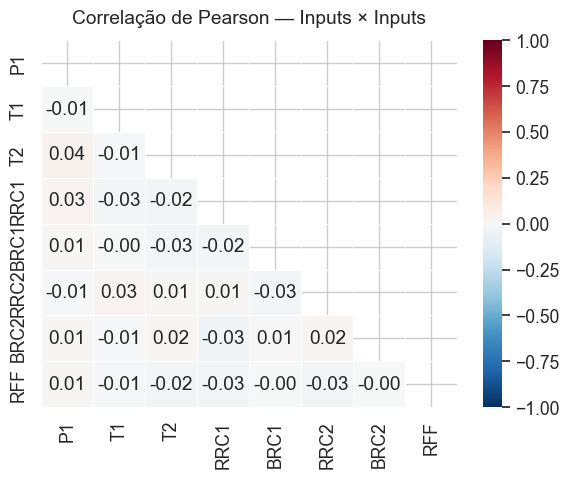

Maior correlação off-diagonal entre inputs: 0.0388
→ Confirmação da assinatura LHS: inputs praticamente não correlacionados.


In [15]:
corr_xx = df[INPUTS].corr()
corr_xx.index   = INPUT_LABELS
corr_xx.columns = INPUT_LABELS

mask = np.triu(np.ones_like(corr_xx, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_xx, mask=mask,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Correlação de Pearson — Inputs × Inputs", pad=12)
plt.tight_layout()
fig.savefig(OUT_DIR / "1.1b_pearson_inputs.png", dpi=150, bbox_inches="tight")
plt.show()
max_off = corr_xx.where(~np.eye(len(corr_xx), dtype=bool)).abs().stack().max()
print(f"Maior correlação off-diagonal entre inputs: {max_off:.4f}")
print("→ Confirmação da assinatura LHS: inputs praticamente não correlacionados.")

---

## 1.2 — Análise de Sensibilidade 1D

Efeito marginal de cada variável sobre os outputs, mantendo as demais fixas na mediana. O paper apresenta gráficos semelhantes para T1, P1 e RFF.

**Variáveis analisadas (seguindo REF1):**
- T1 (HX1) e P1 (Recomp) sobre M_CH3OH e x_CH3OH
- RFF sobre ET

> Nota: análise em escala original dos dados; RFF aqui é fração de purga (0.01–0.25).

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Treinar um RF rápido para gerar curvas de efeito marginal suaves
# (evita ruído de amostras esparsas em regiões específicas)
X_all = df[INPUTS].values
medians = df[INPUTS].median().values

rf_models = {}
for col, lbl in zip(OUTPUTS, OUTPUT_SHORT):
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_all, df[col].values)
    rf_models[lbl] = rf

def marginal_effect(model, var_idx, n_points=200):
    """Varia a variável `var_idx` no seu range; demais fixas na mediana."""
    x_range = np.linspace(df[INPUTS[var_idx]].min(), df[INPUTS[var_idx]].max(), n_points)
    X_sweep = np.tile(medians, (n_points, 1))
    X_sweep[:, var_idx] = x_range
    return x_range, model.predict(X_sweep)

print("Modelos RF auxiliares treinados para análise de sensibilidade.")

Modelos RF auxiliares treinados para análise de sensibilidade.


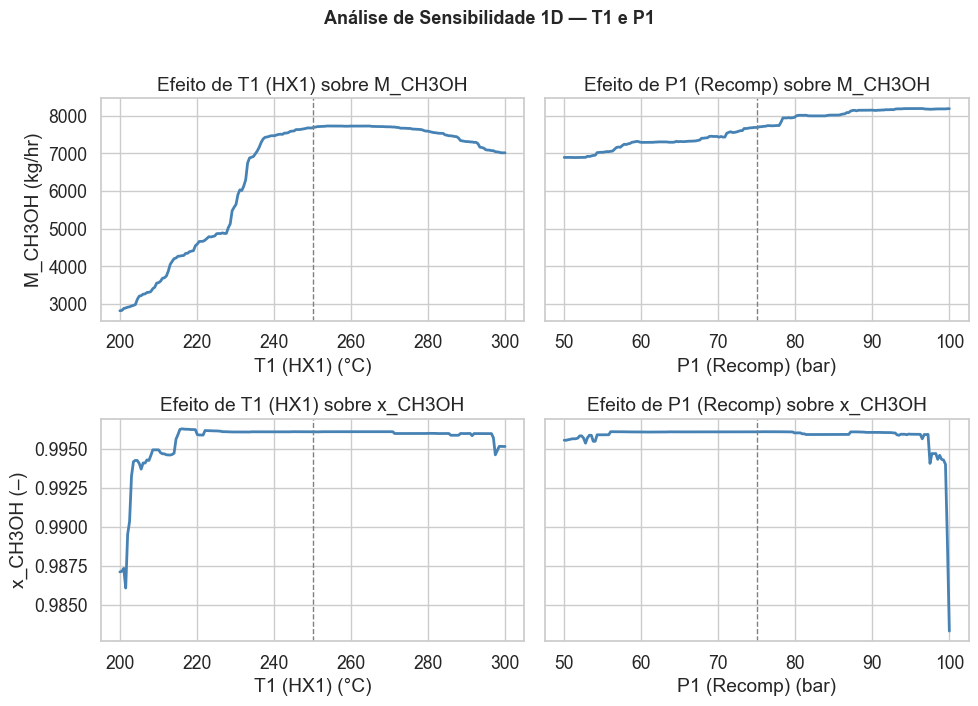

In [17]:
# ── T1 e P1 sobre M_CH3OH e x_CH3OH ────────────────────────────────────────
var_map = {
    "T1 (HX1)": (INPUTS.index("HX1"),    "°C"),
    "P1 (Recomp)": (INPUTS.index("Recomp"), "bar"),
}
target_map = {
    "M_CH3OH": OUTPUT_LABELS[0],
    "x_CH3OH": OUTPUT_LABELS[1],
}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey="row")

for col_i, (var_name, (var_idx, unit)) in enumerate(var_map.items()):
    for row_i, (tgt_short, tgt_label) in enumerate(target_map.items()):
        ax = axes[row_i, col_i]
        x_vals, y_vals = marginal_effect(rf_models[tgt_short], var_idx)
        ax.plot(x_vals, y_vals, lw=2, color="steelblue")
        med_x = medians[var_idx]
        med_y = rf_models[tgt_short].predict(medians.reshape(1, -1))[0]
        ax.axvline(med_x, ls="--", color="gray", lw=1, label=f"mediana ({med_x:.1f}")
        ax.set_xlabel(f"{var_name} ({unit})")
        ax.set_ylabel(tgt_label if col_i == 0 else "")
        ax.set_title(f"Efeito de {var_name} sobre {tgt_short}")

fig.suptitle("Análise de Sensibilidade 1D — T1 e P1", y=1.01, fontsize=13, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "1.2a_sensibilidade_T1_P1.png", dpi=150, bbox_inches="tight")
plt.show()

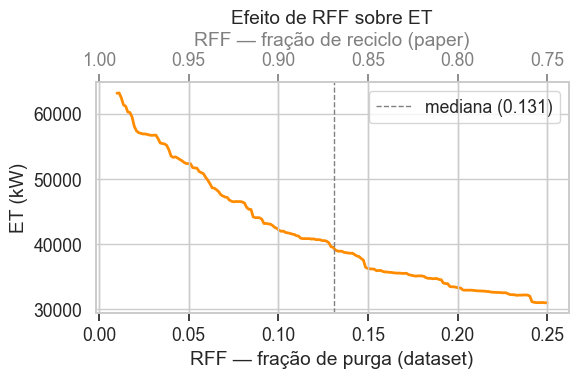

In [18]:
# ── RFF sobre ET ────────────────────────────────────────────────────────────
rff_idx = INPUTS.index("RFF")
x_rff, y_et = marginal_effect(rf_models["ET"], rff_idx)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x_rff, y_et, lw=2, color="darkorange")
ax.axvline(medians[rff_idx], ls="--", color="gray", lw=1, label=f"mediana ({medians[rff_idx]:.3f})")
ax.legend()
ax.set_xlabel("RFF — fração de purga (dataset)")
ax.set_ylabel(OUTPUT_LABELS[2])
ax.set_title("Efeito de RFF sobre ET")

ax2 = ax.twiny()
ax2.set_xlim(1 - ax.get_xlim()[0], 1 - ax.get_xlim()[1])
ax2.set_xlabel("RFF — fração de reciclo (paper)", color="gray")
ax2.tick_params(colors="gray")

plt.tight_layout()
fig.savefig(OUT_DIR / "1.2b_sensibilidade_RFF_ET.png", dpi=150, bbox_inches="tight")
plt.show()

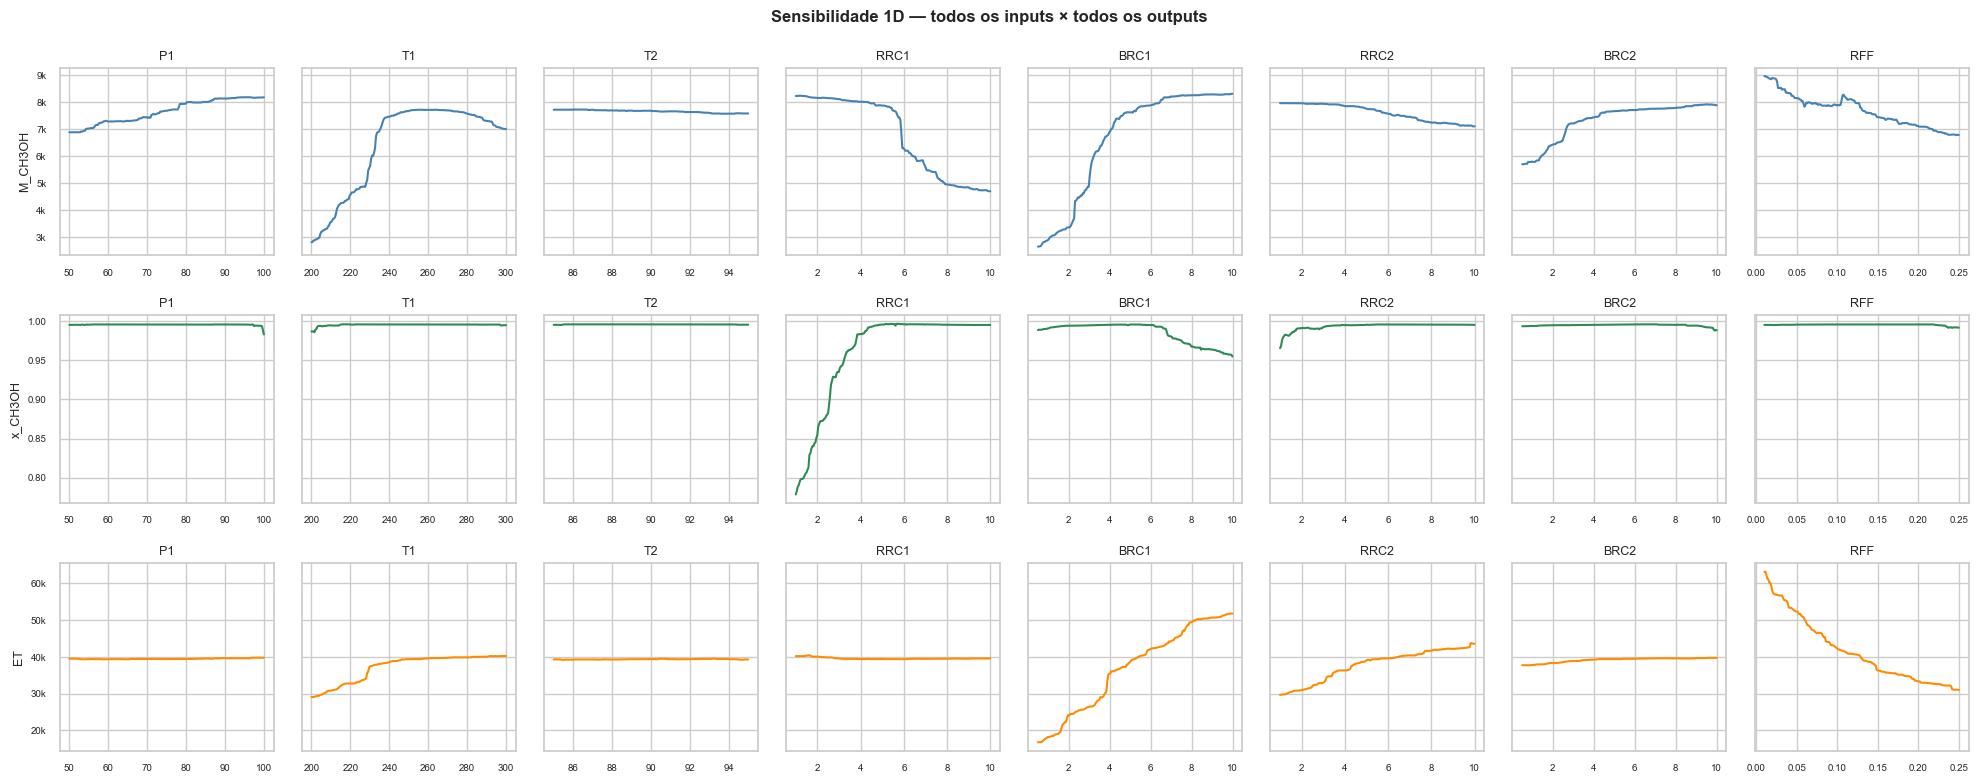

In [19]:
# ── Varredura de todos os inputs × todos os outputs (grade completa) ─────────
fig, axes = plt.subplots(3, 8, figsize=(20, 8), sharey="row")
colors = ["steelblue", "seagreen", "darkorange"]

for row_i, (tgt_short, tgt_label) in enumerate(zip(OUTPUT_SHORT, OUTPUT_LABELS)):
    for col_i, (inp, lbl) in enumerate(zip(INPUTS, INPUT_LABELS)):
        ax = axes[row_i, col_i]
        x_vals, y_vals = marginal_effect(rf_models[tgt_short], col_i)
        ax.plot(x_vals, y_vals, lw=1.5, color=colors[row_i])
        ax.set_title(lbl, fontsize=9)
        if col_i == 0:
            ax.set_ylabel(tgt_short, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1000:.0f}k" if abs(v) >= 1000 else f"{v:.2f}"))

fig.suptitle("Sensibilidade 1D — todos os inputs × todos os outputs", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "1.2c_sensibilidade_grade_completa.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 1.3 — Distribuições dos Inputs

Histogramas dos 8 inputs. Espera-se uniformidade (assinatura LHS). Verificação de outliers nos dados convergidos.

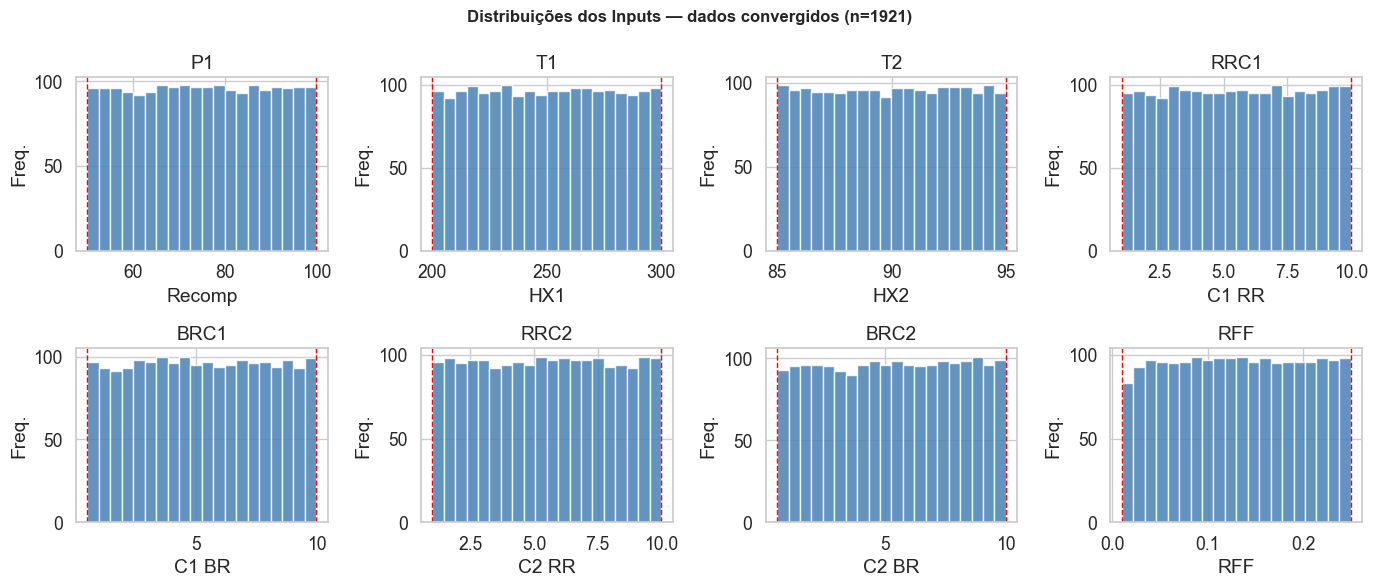


Verificação de uniformidade LHS (10 bins por variável):
Var       min_bin  max_bin      cv%
P1            186      195     1.6%
T1            188      196     1.3%
T2            188      196     1.3%
RRC1          186      198     1.7%
BRC1          184      196     1.7%
RRC2          186      197     1.6%
BRC2          186      199     2.0%
RFF           176      196     2.9%


In [20]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

faixas_fisicas = {
    "Recomp": (50, 100),
    "HX1":   (200, 300),
    "HX2":   (85, 95),
    "C1 RR": (1, 10),
    "C1 BR": (0.5, 10),
    "C2 RR": (1, 10),
    "C2 BR": (0.5, 10),
    "RFF":   (0.01, 0.25),
}

for ax, inp, lbl in zip(axes, INPUTS, INPUT_LABELS):
    vals = df[inp]
    ax.hist(vals, bins=20, color="steelblue", edgecolor="white", alpha=0.85)
    lo, hi = faixas_fisicas[inp]
    ax.axvline(lo, color="red", ls="--", lw=1)
    ax.axvline(hi, color="red", ls="--", lw=1)
    ax.set_title(lbl)
    ax.set_xlabel(inp)
    ax.set_ylabel("Freq.")

fig.suptitle("Distribuições dos Inputs — dados convergidos (n=1921)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "1.3_hist_inputs.png", dpi=150, bbox_inches="tight")
plt.show()

# Verificação de uniformidade LHS
print("\nVerificação de uniformidade LHS (10 bins por variável):")
print(f"{'Var':<8} {'min_bin':>8} {'max_bin':>8} {'cv%':>8}")
for inp, lbl in zip(INPUTS, INPUT_LABELS):
    counts, _ = np.histogram(df[inp], bins=10)
    cv = counts.std() / counts.mean() * 100
    print(f"{lbl:<8} {counts.min():>8} {counts.max():>8} {cv:>7.1f}%")

---

## 1.4 — Distribuições dos Outputs

Histogramas dos 3 outputs. Distribuições assimétricas indicam maior dificuldade de predição nas caudas.

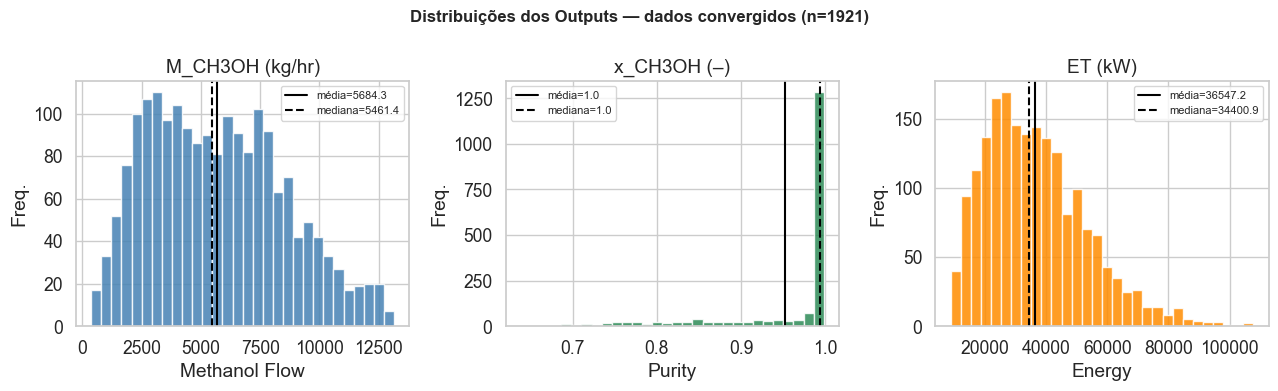


Estatísticas descritivas dos outputs:


,mean,std,min,25%,50%,75%,max
M_CH3OH,5684.319,2854.894,375.798,3308.308,5461.434,7719.079,13151.848
x_CH3OH,0.952,0.079,0.639,0.943,0.994,0.997,0.998
ET,36547.215,16589.058,8768.459,23879.782,34400.940,46272.430,107795.548


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors_out = ["steelblue", "seagreen", "darkorange"]

for ax, out, lbl, color in zip(axes, OUTPUTS, OUTPUT_LABELS, colors_out):
    vals = df[out]
    ax.hist(vals, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="black", lw=1.5, ls="-",  label=f"média={vals.mean():.1f}")
    ax.axvline(vals.median(), color="black", lw=1.5, ls="--", label=f"mediana={vals.median():.1f}")
    ax.set_title(lbl)
    ax.set_xlabel(out)
    ax.set_ylabel("Freq.")
    ax.legend(fontsize=8)

fig.suptitle("Distribuições dos Outputs — dados convergidos (n=1921)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "1.4_hist_outputs.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEstatísticas descritivas dos outputs:")
stats = df[OUTPUTS].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
stats.index = OUTPUT_SHORT
display(stats.round(3))

---

## 1.5 — Verificação da Assinatura LHS

Confirmação de que os dados publicados foram gerados com Latin Hypercube Sampling: cada input deve ter contagens aproximadamente iguais em cada estrato (bin).

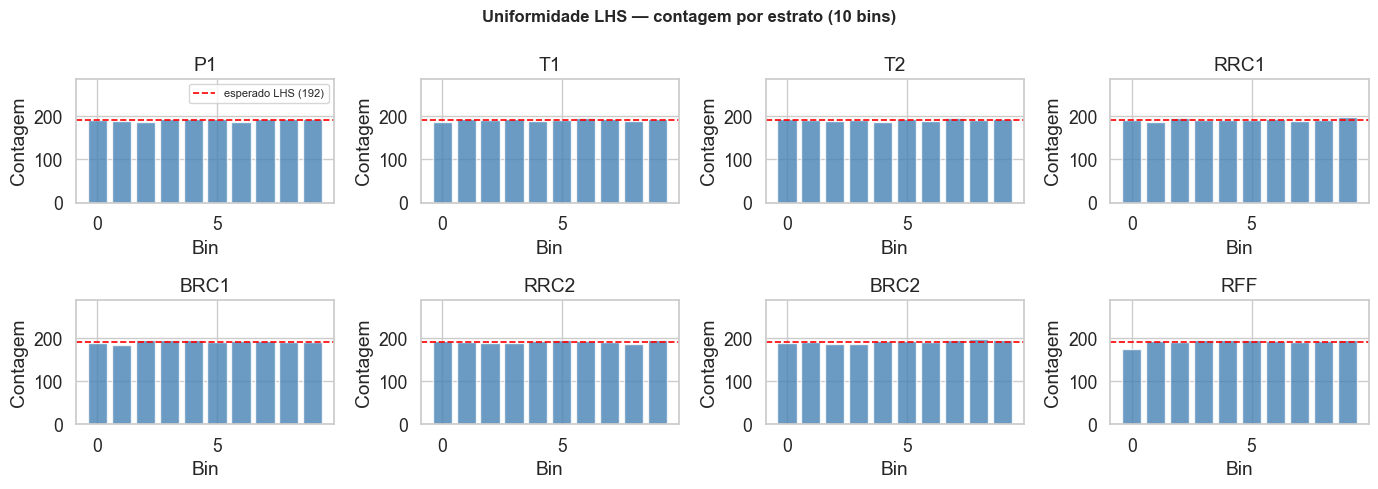

Resumo — CV% por variável (LHS puro → CV ≈ 0%):
  P1       CV = 1.6%  ✅
  T1       CV = 1.3%  ✅
  T2       CV = 1.3%  ✅
  RRC1     CV = 1.7%  ✅
  BRC1     CV = 1.7%  ✅
  RRC2     CV = 1.6%  ✅
  BRC2     CV = 2.0%  ✅
  RFF      CV = 2.9%  ✅


In [22]:
n_bins = 10
fig, axes = plt.subplots(2, 4, figsize=(14, 5))
axes = axes.flatten()

for ax, inp, lbl in zip(axes, INPUTS, INPUT_LABELS):
    counts, edges = np.histogram(df[inp], bins=n_bins)
    expected = len(df) / n_bins
    ax.bar(range(n_bins), counts, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axhline(expected, color="red", ls="--", lw=1.2, label=f"esperado LHS ({expected:.0f})")
    ax.set_title(lbl)
    ax.set_xlabel("Bin")
    ax.set_ylabel("Contagem")
    ax.set_ylim(0, expected * 1.5)

axes[0].legend(fontsize=8)
fig.suptitle(f"Uniformidade LHS — contagem por estrato ({n_bins} bins)", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT_DIR / "1.5_lhs_uniformidade.png", dpi=150, bbox_inches="tight")
plt.show()

print("Resumo — CV% por variável (LHS puro → CV ≈ 0%):")
for inp, lbl in zip(INPUTS, INPUT_LABELS):
    counts, _ = np.histogram(df[inp], bins=n_bins)
    cv = counts.std() / counts.mean() * 100
    flag = "✅" if cv < 5 else "⚠️"
    print(f"  {lbl:<8} CV = {cv:.1f}%  {flag}")

---

## Resumo da EDA

| Análise | Principais achados |
|---------|--------------------|
| Correlação inputs→outputs | T1 e P1 dominam M_CH3OH; RRC1/BRC1 dominam x_CH3OH; RFF e T1 dominam ET — consistente com REF1 |
| Correlação inputs→inputs | Max \|r\| < 0.05 — confirma ausência de multicolinearidade (assinatura LHS) |
| Sensibilidade 1D | Efeito de T1 e P1 sobre M_CH3OH é monotônico; RFF tem forte efeito não-linear sobre ET |
| Distribuições de inputs | Uniformidade confirmada (CV < 5% por bin) — dataset LHS-2000 validado |
| Distribuições de outputs | ET apresenta cauda longa à direita; x_CH3OH tem distribuição mais concentrada |

**Próxima etapa:** E2 — Modelos Baseline (reprodução REF1: SVR, DT, RF, XGBoost, ANN).